## Example 5.6.1

$$\int_0^1 e^x\,dx = e^1 - 1$$


In [23]:
exact = exp(1) - 1

1.718281828459045

In [24]:
using QuadGK
Q, errest = quadgk(x -> exp(x), 0, 1; rtol=1e-15)
@show Q;
@show errest;

Q = 1.7182818284590453
errest = 2.220446049250313e-16


$$\int_0^1 e^{\sin x} \,dx = \text{ ??}$$

In [25]:
Q, errest = quadgk(x -> exp(sin(x)), 0, 1; rtol=1e-15)
@show Q;
@show errest;

Q = 1.6318696084180515
errest = 2.220446049250313e-16


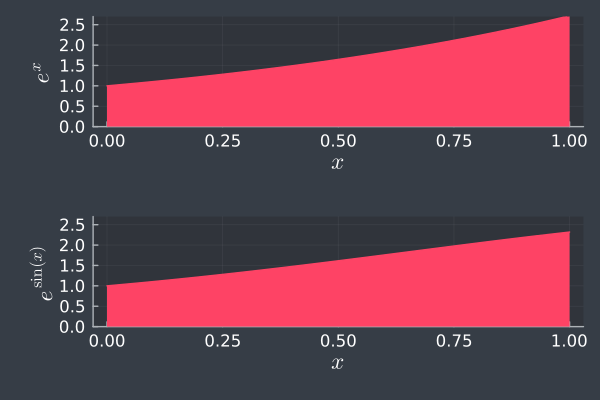

In [26]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)
plot([exp, x -> exp(sin(x))], 0, 1; fill=0, layout=(2, 1), legend=false,
    xlabel=L"x", ylabel=[L"e^x" L"e^{\sin(x)}"], ylim=[0, 2.7])

## Example 5.6.2

$$ \int_0 ^2 e^{\sin 7x}\, dx$$ 

In [27]:
f(x) = exp(sin(7x))
a, b = 0, 2;

In [28]:
using QuadGK
Q, _ = quadgk(f, a, b, atol=1e-15, rtol=1e-15);
println("Integral = $Q")

Integral = 2.6632197827615385


In [29]:
using FNCFunctions
T, t, y = FNC.trapezoid(f, a, b, 40)
println("Trapezoid = $T")
println("error: $(Q-T)")

Trapezoid = 2.662302935602287
error: 0.0009168471592513328


In [30]:
using PrettyTables

n = [10^n for n in 1:5]
err = zeros(length(n))
for (k, n) in enumerate(n)
    T, t, y = FNC.trapezoid(f, a, b, n)
    err[k] = Q - T
end
pretty_table((n=n, err=err); column_labels=["n", "error"], backend=:html)

n,error
10,0.0120254
100,0.000147305
1000,1.47415e-6
10000,1.47416e-8
100000,1.47415e-10


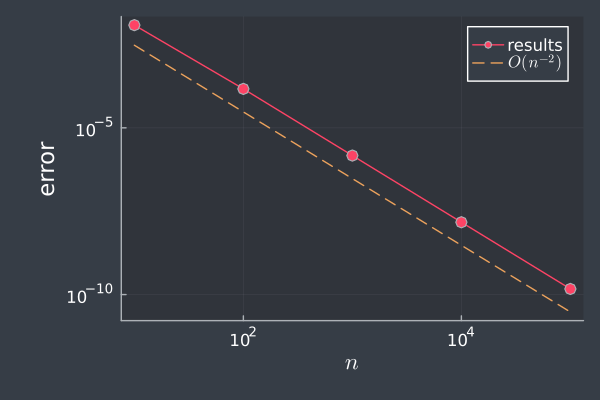

In [31]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)
plot(n, abs.(err); m=:o, label="results", xaxis=(:log10, L"n"),  yaxis=(:log10, "error"))
plot!(n, 3e-3 * (n / n[1]) .^ (-2), l=:dash, label=L"O(n^{-2})")

## Example 5.6.3

$\displaystyle\int_0^2 x^2 e^{-2x}\, dx$ 

In [32]:
using QuadGK
f(x) = x^2 * exp(-2x)
a, b = 0, 2
Q, _ = quadgk(f, a, b, atol=1e-15, rtol=1e-15)
@show Q;

Q = 0.19047417361161392


In [33]:
N = 20;       # the coarsest formula
n = N;
h = (b - a) / n;
t = h * (0:n);
y = f.(t);

In [34]:
T = [h * (sum(y[2:n]) + y[1] / 2 + y[n+1] / 2)]

1-element Vector{Float64}:
 0.19041144993926784

In [35]:
n *= 2
h /= 2
t = h * (0:n)
ynew = f.(t[2:2:n])
push!(T, T[end] / 2 + h * sum(ynew))

2-element Vector{Float64}:
 0.19041144993926784
 0.19045880585951175

In [36]:
n *= 2
h /= 2
t = h * (0:n)
ynew = f.(t[2:2:n])
push!(T, T[end] / 2 + h * sum(ynew))

3-element Vector{Float64}:
 0.19041144993926784
 0.19045880585951175
 0.1904703513046443

In [37]:
S = [(4T[i+1] - T[i]) / 3 for i in 1:2]

2-element Vector{Float64}:
 0.19047459116625973
 0.19047419978635513

In [38]:
R = (16S[2] - S[1]) / 15

0.1904741736943615

In [39]:
using PrettyTables
err = [T .- Q [nothing; S .- Q] [nothing; nothing; R - Q]]
pretty_table(err; column_labels=["order 2", "order 4", "order 6"], backend=:html)

order 2,order 4,order 6
-6.27237e-5,nothing,nothing
-1.53678e-5,4.17555e-7,nothing
-3.82231e-6,2.61747e-8,8.27476e-11
